# MNIST 数据集：从图像矩阵到 784 维向量

这个 notebook 的目标不是训练模型，而是先建立对 MNIST 数据的直观感知：

- 一张手写数字图片在计算机里是什么形状？
- 原始的 $28 \times 28$ 像素矩阵长什么样？
- 为什么深度学习入门里经常把图片 flatten 成 784 维向量？
- train/test split 分别是什么意思？

后续做 logistic regression 或 MLP 时，我们会把每张图片看作一个向量 $x \in \mathbb{R}^{784}$。本节先只关注数据本身。

## 1. 准备环境

MNIST 是一个标准公开数据集，`torchvision.datasets.MNIST` 可以自动下载。第一次运行下面的代码时会下载数据到 `data/`。

In [14]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Seaborn gives all plots a consistent, slide-friendly visual style.
sns.set_theme(style="white", context="notebook", font_scale=1.05)
plt.rcParams["figure.dpi"] = 150

# Put downloaded MNIST files in the repository-level data/ directory.
# This works whether the notebook kernel starts from the repo root or from dl_intro/.
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "dl_intro" else Path.cwd()
DATA_DIR = REPO_ROOT / "data"

# ToTensor converts a PIL image with pixel values 0..255 into a tensor with values 0..1.
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(root=DATA_DIR, train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root=DATA_DIR, train=False, download=True, transform=transform)

len(train_dataset), len(test_dataset)

(60000, 10000)

## 2. 官方 train/test split

MNIST 已经提供了一个官方划分：

- training set：60,000 张图片，用来学习模型参数。
- test set：10,000 张图片，用来在训练结束后评估模型。

测试集不应该用来调参。否则，模型可能只是“适应了测试集”，不能代表真正的泛化能力。

In [15]:
split_summary = pd.DataFrame(
    {
        "split": ["train", "test"],
        "number_of_images": [len(train_dataset), len(test_dataset)],
        "purpose": ["learn model parameters", "final evaluation"],
    }
)

split_summary

,split,number_of_images,purpose
0,train,60000,learn model parameters
1,test,10000,final evaluation


每张图片都有一个标签，标签是 0 到 9 之间的整数。下面看一下不同数字在 train/test 中的数量是否大致均衡。

In [16]:
def count_labels(dataset):
    labels = dataset.targets.numpy()
    counts = np.bincount(labels, minlength=10)
    return counts


label_counts = pd.DataFrame(
    {
        "digit": np.arange(10),
        "train_count": count_labels(train_dataset),
        "test_count": count_labels(test_dataset),
    }
)

label_counts

,digit,train_count,test_count
0,0,5923,980
1,1,6742,1135
2,2,5958,1032
3,3,6131,1010
4,4,5842,982
5,5,5421,892
6,6,5918,958
7,7,6265,1028
8,8,5851,974
9,9,5949,1009


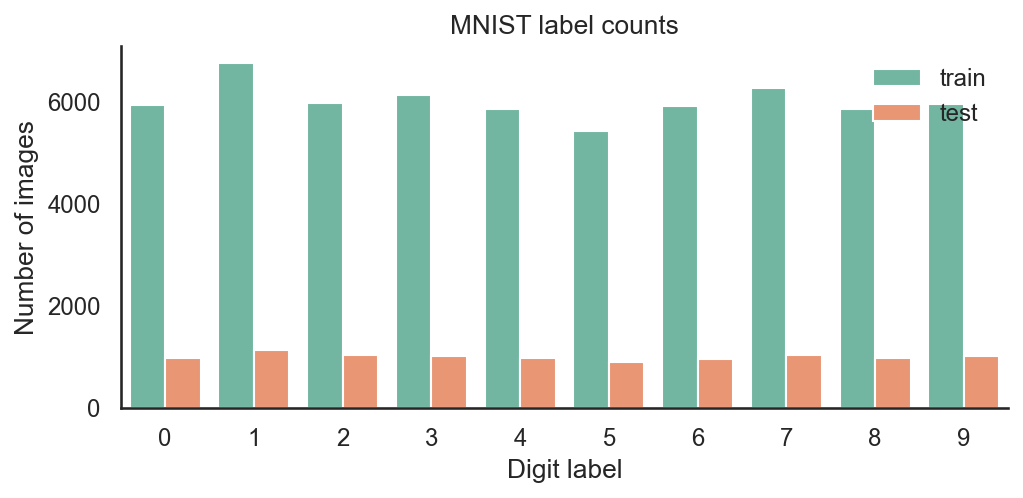

In [17]:
plot_counts = label_counts.melt(
    id_vars="digit",
    value_vars=["train_count", "test_count"],
    var_name="split",
    value_name="number_of_images",
)
plot_counts["split"] = plot_counts["split"].str.replace("_count", "", regex=False)

fig, ax = plt.subplots(figsize=(7, 3.5))
sns.barplot(
    data=plot_counts,
    x="digit",
    y="number_of_images",
    hue="split",
    palette="Set2",
    ax=ax,
)
ax.set_xlabel("Digit label")
ax.set_ylabel("Number of images")
ax.set_title("MNIST label counts")
ax.legend(title=None, frameon=False)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

## 3. 一张 MNIST 图片的数据形式

从 `train_dataset[i]` 取出一个样本，会得到：

- `image`: PyTorch tensor，形状是 `(1, 28, 28)`。
- `label`: 这张图对应的数字类别。

这里的 `1` 表示 channel 数。MNIST 是灰度图，所以只有 1 个 channel。彩色 RGB 图片通常有 3 个 channel。

In [18]:
sample_index = 0
image, label = train_dataset[sample_index]

print(f"label = {label}")
print(f"image.shape = {tuple(image.shape)}")
print(f"image dtype = {image.dtype}")
print(f"min pixel value = {image.min().item():.3f}")
print(f"max pixel value = {image.max().item():.3f}")

label = 5
image.shape = (1, 28, 28)
image dtype = torch.float32
min pixel value = 0.000
max pixel value = 1.000


`torchvision` 同时保存了原始像素矩阵。原始矩阵是整数，范围是 0 到 255；经过 `ToTensor()` 后，数值被缩放到 0 到 1。

In [19]:
# Raw pixel matrix before ToTensor(): shape is 28 x 28, values are integers from 0 to 255.
raw_matrix = train_dataset.data[sample_index]

# Tensor image after ToTensor(): shape is 1 x 28 x 28, values are floats from 0 to 1.
scaled_matrix = image.squeeze(0)

print(f"raw_matrix.shape = {tuple(raw_matrix.shape)}")
print(f"raw_matrix dtype = {raw_matrix.dtype}")
print(f"scaled_matrix.shape = {tuple(scaled_matrix.shape)}")
print(f"scaled_matrix dtype = {scaled_matrix.dtype}")

raw_matrix.shape = (28, 28)
raw_matrix dtype = torch.uint8
scaled_matrix.shape = (28, 28)
scaled_matrix dtype = torch.float32


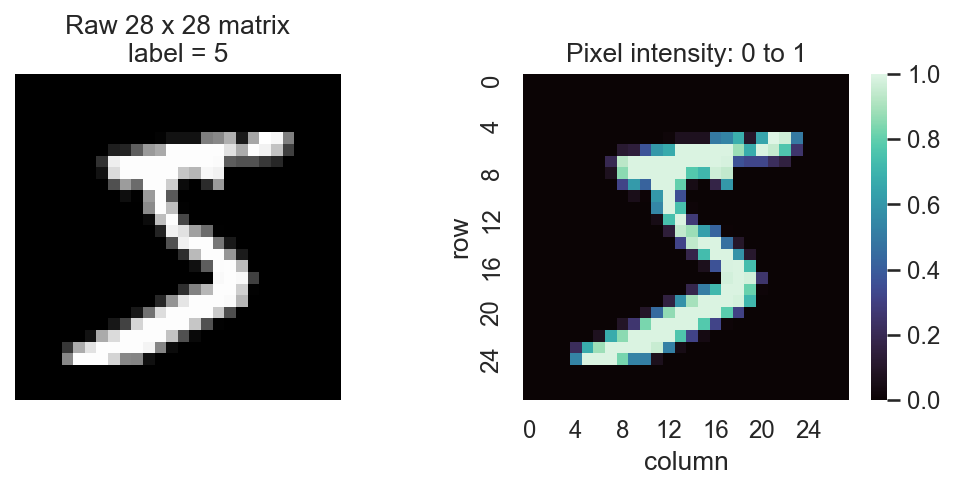

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(7, 3.2))

sns.heatmap(
    raw_matrix.numpy(),
    cmap="gray",
    cbar=False,
    square=True,
    xticklabels=False,
    yticklabels=False,
    ax=axes[0],
)
axes[0].set_title(f"Raw 28 x 28 matrix\nlabel = {label}")

sns.heatmap(
    scaled_matrix.numpy(),
    cmap="mako",
    vmin=0,
    vmax=1,
    cbar=True,
    square=True,
    xticklabels=4,
    yticklabels=4,
    ax=axes[1],
)
axes[1].set_title("Pixel intensity: 0 to 1")
axes[1].set_xlabel("column")
axes[1].set_ylabel("row")

plt.tight_layout()
plt.show()

也可以直接打印像素矩阵。下面只打印中间的一小块区域，避免输出太长。数值越大，表示该像素越亮。

In [21]:
# Show a central 10 x 10 block of the original pixel matrix.
center_block = raw_matrix[9:19, 9:19]
center_block

tensor([[156, 107, 253, 253, 205,  11,   0,  43, 154,   0],
        [ 14,   1, 154, 253,  90,   0,   0,   0,   0,   0],
        [  0,   0, 139, 253, 190,   2,   0,   0,   0,   0],
        [  0,   0,  11, 190, 253,  70,   0,   0,   0,   0],
        [  0,   0,   0,  35, 241, 225, 160, 108,   1,   0],
        [  0,   0,   0,   0,  81, 240, 253, 253, 119,  25],
        [  0,   0,   0,   0,   0,  45, 186, 253, 253, 150],
        [  0,   0,   0,   0,   0,   0,  16,  93, 252, 253],
        [  0,   0,   0,   0,   0,   0,   0,   0, 249, 253],
        [  0,   0,   0,   0,   0,  46, 130, 183, 253, 253]], dtype=torch.uint8)

## 4. 从矩阵到向量：flatten

对一张图片来说，原始表示是一个矩阵：

$$
\text{image matrix} \in \mathbb{R}^{28 \times 28}
$$

很多最基础的分类模型，例如 logistic regression，会把图片展平成一个长向量：

$$
x \in \mathbb{R}^{784}, \quad 784 = 28 \times 28
$$

flatten 不会改变像素值，只是改变排列形状。

In [22]:
# Remove the channel dimension and flatten 28 x 28 pixels into a 784-dimensional vector.
image_matrix = image.squeeze(0)      # shape: (28, 28)
image_vector = image_matrix.reshape(-1)  # shape: (784,)

print(f"image_matrix.shape = {tuple(image_matrix.shape)}")
print(f"image_vector.shape = {tuple(image_vector.shape)}")
print(f"first 20 values in the flattened vector:\n{image_vector[:20]}")

image_matrix.shape = (28, 28)
image_vector.shape = (784,)
first 20 values in the flattened vector:
tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])


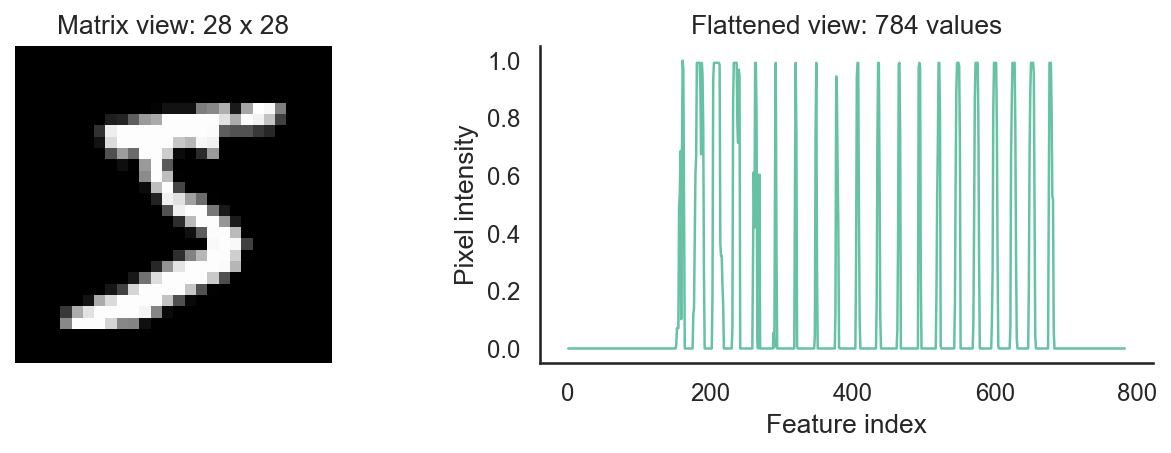

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))

sns.heatmap(
    image_matrix.numpy(),
    cmap="gray",
    cbar=False,
    square=True,
    xticklabels=False,
    yticklabels=False,
    ax=axes[0],
)
axes[0].set_title("Matrix view: 28 x 28")

vector_df = pd.DataFrame({"feature_index": np.arange(784), "pixel_intensity": image_vector.numpy()})
sns.lineplot(
    data=vector_df,
    x="feature_index",
    y="pixel_intensity",
    color=sns.color_palette("Set2")[0],
    linewidth=1.2,
    ax=axes[1],
)
axes[1].set_title("Flattened view: 784 values")
axes[1].set_xlabel("Feature index")
axes[1].set_ylabel("Pixel intensity")
axes[1].set_ylim(-0.05, 1.05)
sns.despine(ax=axes[1])

plt.tight_layout()
plt.show()

对于一个 batch，形状会多出 batch size 这一维。若 batch size 是 $B$，那么：

- 原始 batch 图片：`images.shape = (B, 1, 28, 28)`
- 展平后：`X.shape = (B, 784)`
- 标签：`labels.shape = (B,)`

这就是后续线性分类器输入矩阵 $X$ 的来源。

In [24]:
batch_size = 8
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

images, labels = next(iter(train_loader))
X = images.view(images.shape[0], -1)

print(f"images.shape = {tuple(images.shape)}")
print(f"X.shape = {tuple(X.shape)}")
print(f"labels.shape = {tuple(labels.shape)}")
print(f"labels = {labels.tolist()}")

images.shape = (8, 1, 28, 28)
X.shape = (8, 784)
labels.shape = (8,)
labels = [1, 2, 8, 5, 2, 6, 9, 9]


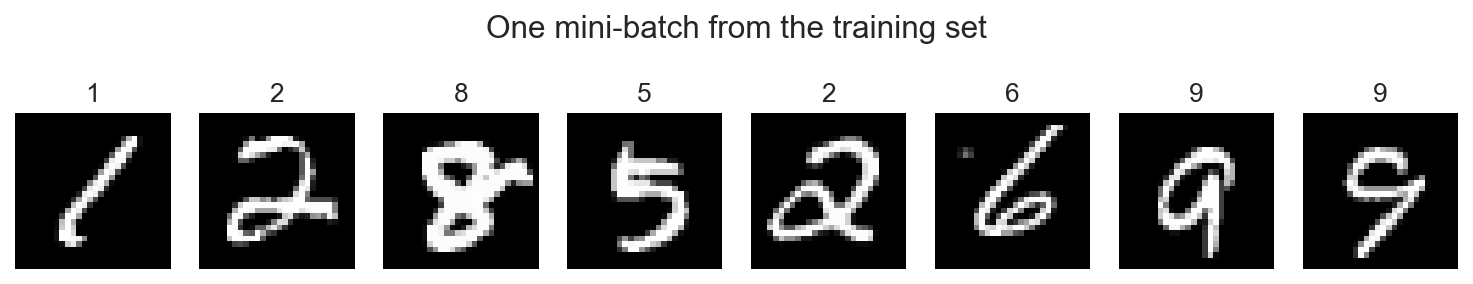

In [25]:
fig, axes = plt.subplots(1, batch_size, figsize=(10, 1.8))

for axis, image_i, label_i in zip(axes, images, labels):
    sns.heatmap(
        image_i.squeeze(0).numpy(),
        cmap="gray",
        cbar=False,
        square=True,
        xticklabels=False,
        yticklabels=False,
        ax=axis,
    )
    axis.set_title(str(label_i.item()))
    axis.set_xlabel("")
    axis.set_ylabel("")

plt.suptitle("One mini-batch from the training set", y=1.05)
plt.tight_layout()
plt.show()

## 5. 连接到后续模型

如果一个 batch 有 $B$ 张图片，flatten 后得到：

$$
X \in \mathbb{R}^{B \times 784}
$$

在 10 类数字分类中，一个最简单的线性模型会产生 10 个 logits：

$$
S = XW + b
$$

其中：

- $X$ 的形状是 $(B, 784)$。
- $W$ 的形状是 $(784, 10)$。
- $b$ 的形状是 $(10,)$。
- $S$ 的形状是 $(B, 10)$，每一行对应一张图片的 10 个类别分数。

本 notebook 只解释数据。下一步才是学习如何从 $X$ 得到 logits、softmax 概率和 cross-entropy loss。